# Tokenizer Efficiency Across Languages

Im trilingual (Russian, Mongolian, English) and noticed AI tools consistently 
struggle more with Mongolian than my other languages. It has bad pronunciation, and
worse translation quality. This project tests one concrete hypothesis for why: 
tokenizers encode some languages far less efficiently than others, which means 
the model spends more of its limited context/compute just representing the 
text before it can reason about it.

**Method**: FLORES-200 (Metas parallel evaluation corpus; so it's the same sentences, 
professionally translated into 200 languages) run through 5 different 
tokenizers. measuring token count per language relative to English.

In [8]:
import tiktoken
from transformers import AutoTokenizer
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
LANG_CODES = {
    "english": "eng_Latn",
    "russian": "rus_Cyrl",
    "mongolian": "khk_Cyrl",
    "japanese": "jpn_Jpan",
    "czech": "ces_Latn",
}
N_SENTENCES = 200

In [10]:
def load_flores_sentences():
    sentences = {}
    for lang_name, code in LANG_CODES.items():
        ds = load_dataset("facebook/flores", code, split="dev")
        sentences[lang_name] = [row["sentence"] for row in ds][:N_SENTENCES]
    return sentences

sentences = load_flores_sentences()
print({k: len(v) for k, v in sentences.items()})  # sanity check: should print 200 for each language

{'english': 200, 'russian': 200, 'mongolian': 200, 'japanese': 200, 'czech': 200}


## Results

Token count for each language, normalized against English (1.0 = same 
efficiency as English; higher = more tokens needed for the same content).

In [15]:
tokenizers = {}
tokenizers["gpt-4o (o200k_base)"] = ("tiktoken", tiktoken.get_encoding("o200k_base"))
tokenizers["gpt-4 (cl100k_base)"] = ("tiktoken", tiktoken.get_encoding("cl100k_base"))
tokenizers["nllb-200"] = ("hf", AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M"))
tokenizers["mbert"] = ("hf", AutoTokenizer.from_pretrained("bert-base-multilingual-cased"))
tokenizers["llama-3"] = ("hf", AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B"))
tokenizers["mistral"] = ("hf", AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1"))

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

In [16]:
def count_tokens(tok_type, tok, text):
    return len(tok.encode(text))

results = {name: {} for name in tokenizers}
for tok_name, (tok_type, tok) in tokenizers.items():
    for lang, sents in sentences.items():
        results[tok_name][lang] = sum(count_tokens(tok_type, tok, s) for s in sents)

results

{'gpt-4o (o200k_base)': {'english': 5440,
  'russian': 7959,
  'mongolian': 10397,
  'japanese': 9127,
  'czech': 8354},
 'gpt-4 (cl100k_base)': {'english': 5469,
  'russian': 13629,
  'mongolian': 20466,
  'japanese': 12412,
  'czech': 10875},
 'nllb-200': {'english': 6436,
  'russian': 8745,
  'mongolian': 8914,
  'japanese': 6809,
  'czech': 7890},
 'mbert': {'english': 6125,
  'russian': 8916,
  'mongolian': 11994,
  'japanese': 9551,
  'czech': 8435},
 'llama-3': {'english': 5667,
  'russian': 9417,
  'mongolian': 17842,
  'japanese': 8630,
  'czech': 8240},
 'mistral': {'english': 6324,
  'russian': 11645,
  'mongolian': 18232,
  'japanese': 13313,
  'czech': 10981}}

In [17]:
rows = []
for tok_name, lang_counts in results.items():
    en_count = lang_counts["english"]
    for lang, count in lang_counts.items():
        rows.append({
            "tokenizer": tok_name,
            "language": lang,
            "tokens": count,
            "ratio_vs_english": count / en_count,
        })

df = pd.DataFrame(rows)
df_pivot = df.pivot(index="language", columns="tokenizer", values="ratio_vs_english")
df_pivot

tokenizer,gpt-4 (cl100k_base),gpt-4o (o200k_base),llama-3,mbert,mistral,nllb-200
language,,,,,,
czech,1.988481,1.535662,1.454032,1.377143,1.736401,1.225917
english,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
japanese,2.269519,1.677757,1.522852,1.559347,2.105155,1.057955
mongolian,3.742183,1.911213,3.148403,1.958204,2.882985,1.385022
russian,2.492046,1.463051,1.661726,1.455673,1.841398,1.358763


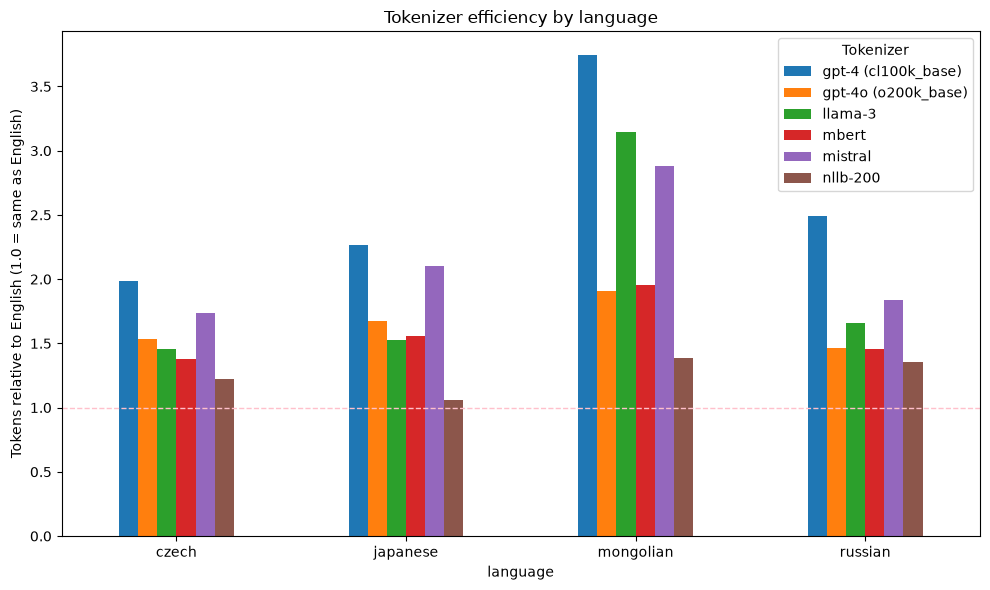

In [21]:
ax = df_pivot.drop(index="english").plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Tokens relative to English (1.0 = same as English)")
ax.set_title("Tokenizer efficiency by language")
ax.axhline(1.0, color="pink", linestyle="--", linewidth=1)
plt.xticks(rotation=0)
plt.legend(title="Tokenizer")
plt.tight_layout()
plt.savefig("tokenizer_efficiency_chart.png", dpi=200)
plt.show()

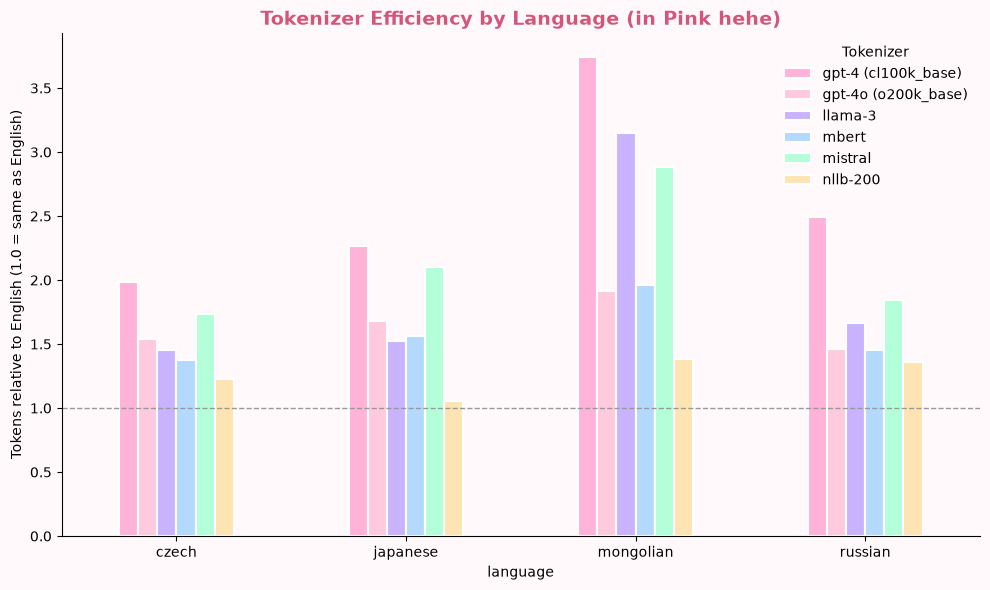

In [24]:
pastel_colors = ["#FFB3D9", "#FFC9DE", "#C9B3FF", "#B3D9FF", "#B3FFD9", "#FFE4B3"]

ax = df_pivot.drop(index="english").plot(
    kind="bar",
    figsize=(10, 6),
    color=pastel_colors,
    edgecolor="white",
    linewidth=1.5,
)
ax.set_ylabel("Tokens relative to English (1.0 = same as English)")
ax.set_title("Tokenizer Efficiency by Language (in Pink hehe)", fontsize=14, fontweight="bold", color="#D4547A")
ax.axhline(1.0, color="#999999", linestyle="--", linewidth=1)
ax.set_facecolor("#FFF9FB")
plt.gcf().set_facecolor("#FFF9FB")
plt.xticks(rotation=0)
plt.legend(title="Tokenizer", frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("tokenizer_efficiency_chart.png", dpi=200)
plt.show()

## Findings

Mongolian is the least efficiently tokenized language across all 5 tokenizers 
tested, ranging from 1.39x more tokens (NLLB-200) to 3.74x more tokens 
(GPT-4's cl100k_base) than English for identical content.

The clearest pattern is by tokenizer *purpose*, not just architecture: 
general-purpose tokenizers (GPT-4, Mistral) show the worst multilingual 
efficiency, while NLLB-200. It's built specifically for 200 languages and is 
consistently the best performer (roughly 2.7x more efficient than GPT-4 on 
the same Mongolian text - that's pretty good!)

This isn't just a translation inconvenience. More tokens per unit of meaning 
means less effective context window and higher inference cost for speakers 
of these languages, and it's evidence the gap is a design choice, not an 
unavoidable limit. NLLB proves it's solvable when multilingual coverage is 
a first-class training goal rather than an afterthought.

**Potential next steps**: scale to the full FLORES-200 set (~1000 sentences vs. the 
200 used here), add Llama 3 once my model access is approved, and test whether 
the gap is about the language or the script by comparing Mongolian in 
Cyrillic vs. traditional Mongolian script.